In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy.stats
import torch

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import block_formats.quantisation as Q
import plot_utils

def get_generator(seed: int = 0) -> torch.random.Generator:
    return torch.Generator().manual_seed(int(np.random.SeedSequence(seed).generate_state(1)[0]))

plot_utils.configure()

Recommend (Ubuntu):
  sudo apt-get install cm-super dvipng fonts-cmu texlive-latex-extra


remote: Updating references: 100% (1/1)           


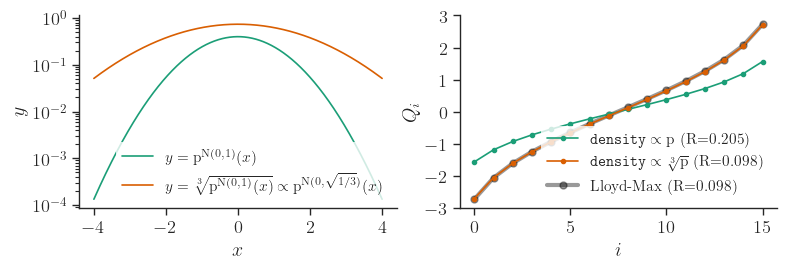

In [ ]:
_, (ax0, ax1) = plt.subplots(ncols=2, figsize=(9, 2.5))

x = torch.linspace(-4, 4, 1001)
ax0.plot(x, scipy.stats.norm.pdf(x), label=r"$y = \mathrm{p}^{\mathrm{N}(0, 1)}(x)$")
ax0.plot(x, scipy.stats.norm.pdf(x)**(1/3), label=r"$y = \sqrt[3]{\mathrm{p}^{\mathrm{N}(0, 1)}(x)} \propto \mathrm{p}^{\mathrm{N}(0, \sqrt{1/3})}(x)$")
ax0.set_yscale("log")
ax0.set_xlabel("$x$")
ax0.set_ylabel(r"$y$")
ax0.legend(loc="lower right")

bits = 4
# n_X, iterations, push = 2**14, 100, False
n_X, iterations, push = 2**20, 200, True

X = torch.randn(n_X, generator=get_generator())
for fmt in [
        Q.crd_gauss(bits, multiplier=1),
        Q.crd_gauss(bits),
        Q.lut_lloyd_max(torch.randn(n_X, generator=get_generator(1)), bits, iterations=iterations),
    ]:
    args = dict(c="k", zorder=0, lw=3, ms=5, alpha=.4) if fmt.name == "LM" else {}
    name = {
        "CRD-G{1}": r"$\texttt{density} \propto \mathrm{p}$",
        "CRD-G": r"$\texttt{density} \propto \sqrt[3]{\mathrm{p}}$",
        "LM": r"Lloyd-Max",
    }[fmt.name]
    rmse = Q.rmse_norm(X, fmt.quantise(X)).item()
    ax1.plot(fmt.values, marker="o", label=f"{name} (R={rmse:.3f})", **args)
ax1.set_yticks(list(range(-3, 3+1)))
ax1.set_xlabel("$i$")
ax1.set_ylabel("$Q_i$")
ax1.legend(loc="lower right")

plot_utils.save("normal_crd_example_4bit", push=push)

/tmp/ipykernel_3431/996834840.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax0.legend(loc="lower right")


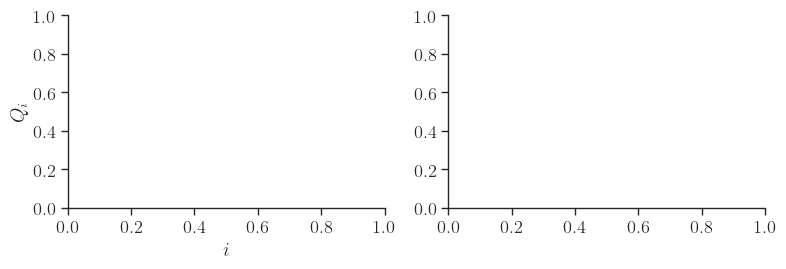

In [5]:
_, (ax0, ax1) = plt.subplots(ncols=2, figsize=(9, 2.5))

bits = 4
n_X, iterations, push = 2**14, 100, False
# n_X, iterations, push = 2**20, 200, True

X = torch.randn(n_X, generator=get_generator())
for fmt in ["normal", "laplace", "student-t-4"]:
    pass # TODO
ax0.set_xlabel("$i$")
ax0.set_ylabel("$Q_i$")
ax0.legend(loc="lower right")

# plot_utils.save("crd_curves_4bit", push=push)